In [1]:
import pandas as pd
import re
import contractions
import nltk
import numpy as np
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel

DATA_PATH = "../data/comcast_consumeraffairs_complaints.csv"

In [2]:
df = pd.read_csv(DATA_PATH)

# nur Textspalte behalten
df = df[["text"]].copy()
#NaN entfernen
df = df.dropna(subset=["text"]) 
#Texttyp String
df["text"] = df["text"].astype(str)

# leere / whitespace-only Einträge und Duplikate entfernen
df = df[df["text"].str.strip().ne("")]
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)

df.shape

(5628, 1)

In [3]:
STOP = set(stopwords.words("english"))
# Festlegung von Stoppwörtern die erhalten bleiben sollen
NEGATIONS = {"no", "not", "nor", "never", "n't"}
STOP = STOP - NEGATIONS

# Domänenspezifische Stopwords die entfernt werden sollen
STOP |= {"comcast", "xfinity"}

# zusätzlich neu hinzugefügte Stoppwörter zur Verbesserung der Analyse
EXTRA_STOP = {"would", "said", "told", "could", "also", "really", "even", "time", "day", "hour", "minute", "one", "people","still","january","february","march","april","may","june","july","august",
         "september","october","november","december", "wa", "ha", "doe", "got", "go"}
STOP |= EXTRA_STOP

lemmatizer = WordNetLemmatizer()

url_re = re.compile(r"https?://\S+|www\.\S+")
email_re = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b")
num_re = re.compile(r"\b\d+([\.,]\d+)?\b")
non_letter_re = re.compile(r"[^a-zA-Z\s]+")

def preprocess_tokens(text: str):
    text = contractions.fix(text).lower()
    text = url_re.sub(" ", text)
    text = email_re.sub(" ", text)
    text = num_re.sub(" ", text)
    text = non_letter_re.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if t not in STOP]
    return tokens

df["tokens"] = df["text"].apply(preprocess_tokens)
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

texts = df["clean_text"] #für sklearn
texts_tokens = df["tokens"].tolist() #für gensim

dictionary = Dictionary(texts_tokens)
dictionary.filter_extremes(no_below=10, no_above=0.6)



In [4]:
# Prüfung ob der bereinigte Text aussieht wie erwartet
df["clean_text"] = df["text"].astype(str).apply(preprocess_tokens)
df[["text", "clean_text"]].sample(3, random_state=42)

,text,clean_text
4331,After waiting on hold for more than 10 minutes...,"[waiting, hold, spoke, representative, explain..."
1988,I pay so much for Comcast and their so-called ...,"[pay, much, called, premium, channel, free, mo..."
3443,I would like to give Comcast NEGATIVE stars......,"[like, give, negative, star, many, negative, s..."


In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# texts = df["clean_text"] #für sklearn

bow_vec = CountVectorizer(min_df=10, max_df=0.6, ngram_range=(1,2))
tfidf_vec = TfidfVectorizer(min_df=10, max_df=0.6, ngram_range=(1,2))

X_bow = bow_vec.fit_transform(texts)
X_tfidf = tfidf_vec.fit_transform(texts)

X_bow.shape, X_tfidf.shape


((5628, 8294), (5628, 8294))

In [6]:
# --- Top Begriffe nach Gesamt-Häufigkeit (BoW) ---
terms_bow = np.array(bow_vec.get_feature_names_out())
counts = np.asarray(X_bow.sum(axis=0)).ravel()
top_bow = terms_bow[counts.argsort()[::-1][:25]]

# --- Top Begriffe nach durchschnittlicher TF-IDF (über alle Dokumente) ---
terms_tfidf = np.array(tfidf_vec.get_feature_names_out())
mean_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_tfidf = terms_tfidf[mean_tfidf.argsort()[::-1][:25]]

print("Top BoW:", top_bow)
print("Top TF-IDF:", top_tfidf)


Top BoW: ['call' 'called' 'customer' 'get' 'internet' 'bill' 'month' 'phone'
 'cable' 'back' 'problem' 'box' 'never' 'account' 'customer service' 'new'
 'pay' 'year' 'company' 'tech' 'another' 'work' 'charge' 'technician'
 'home']
Top TF-IDF: ['call' 'bill' 'internet' 'customer' 'month' 'called' 'get' 'cable'
 'phone' 'problem' 'back' 'box' 'account' 'never' 'year'
 'customer service' 'company' 'pay' 'new' 'charge' 'tech' 'technician'
 'work' 'modem' 'week']


In [7]:
n_topics = 11
svd = TruncatedSVD(n_components=n_topics, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)

terms = np.array(tfidf_vec.get_feature_names_out())

def show_lsa_topics(model, terms, topn=10):
    for i, comp in enumerate(model.components_):
        top_ids = np.argsort(np.abs(comp))[::-1][:topn]
        print(f"LSA Topic {i}: {', '.join(terms[top_ids])}")

show_lsa_topics(svd, terms, topn=10)


LSA Topic 0: call, bill, called, customer, internet, month, get, phone, cable, back
LSA Topic 1: bill, month, tech, appointment, technician, call, fee, payment, charge, pay
LSA Topic 2: speed, internet, account, channel, call, mbps, cable, called, payment, number
LSA Topic 3: box, channel, speed, cable, internet, cable box, mbps, digital, customer, dvr
LSA Topic 4: customer, modem, channel, customer service, bill, contract, speed, tech, company, price
LSA Topic 5: account, bill, box, month, appointment, modem, equipment, channel, tech, called
LSA Topic 6: modem, payment, equipment, contract, cable, fee, package, bill, get, problem
LSA Topic 7: speed, channel, modem, mbps, problem, called, company, package, year, equipment
LSA Topic 8: customer, customer service, box, channel, phone, speed, number, technician, mbps, get
LSA Topic 9: technician, cable, call, modem, tech, back, appointment, internet, get, year
LSA Topic 10: channel, modem, box, technician, contract, customer, problem, equ

In [8]:
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
X_lda = lda.fit_transform(X_bow)

terms_b = np.array(bow_vec.get_feature_names_out())

def show_lda_topics(model, terms, topn=10):
    for i, topic in enumerate(model.components_):
        top_ids = topic.argsort()[::-1][:topn]
        print(f"LDA Topic {i}: {', '.join(terms[top_ids])}")

show_lda_topics(lda, terms_b, topn=10)


LDA Topic 0: box, channel, cable, digital, dvr, movie, watch, pay, basic, cable box
LDA Topic 1: cable, called, appointment, call, box, come, get, home, technician, came
LDA Topic 2: problem, tech, technician, internet, phone, call, home, work, called, modem
LDA Topic 3: internet, speed, mbps, high, modem, internet service, month, high speed, speed internet, connection
LDA Topic 4: customer, phone, number, call, customer service, representative, business, account, email, issue
LDA Topic 5: month, year, contract, customer, price, package, get, bill, internet, called
LDA Topic 6: modem, call, house, voice, supervisor, box, signal, back, rewire, mail
LDA Topic 7: bill, month, credit, charge, equipment, called, pay, account, get, paid
LDA Topic 8: account, payment, fee, pay, address, due, bank, made, agent, year
LDA Topic 9: call, back, called, phone, supervisor, get, customer, hold, someone, call back
LDA Topic 10: get, company, customer, cable, internet, problem, year, never, work, every

In [9]:
lda_top_topic = X_lda.argmax(axis=1)
lda_counts = np.bincount(lda_top_topic, minlength=n_topics)

for i in lda_counts.argsort()[::-1]:
    print(f"LDA Topic {i}: {lda_counts[i]} Dokumente")

LDA Topic 10: 1221 Dokumente
LDA Topic 7: 824 Dokumente
LDA Topic 2: 713 Dokumente
LDA Topic 5: 674 Dokumente
LDA Topic 9: 654 Dokumente
LDA Topic 4: 604 Dokumente
LDA Topic 1: 402 Dokumente
LDA Topic 8: 219 Dokumente
LDA Topic 3: 162 Dokumente
LDA Topic 0: 145 Dokumente
LDA Topic 6: 10 Dokumente


In [10]:
lsa_top_topic = np.abs(X_lsa).argmax(axis=1)
lsa_counts = np.bincount(lsa_top_topic, minlength=n_topics)

for i in lsa_counts.argsort()[::-1]:
    print(f"LSA Topic {i}: {lsa_counts[i]} Dokumente")


LSA Topic 0: 4958 Dokumente
LSA Topic 2: 164 Dokumente
LSA Topic 1: 128 Dokumente
LSA Topic 3: 111 Dokumente
LSA Topic 6: 64 Dokumente
LSA Topic 4: 44 Dokumente
LSA Topic 10: 40 Dokumente
LSA Topic 8: 35 Dokumente
LSA Topic 5: 35 Dokumente
LSA Topic 7: 30 Dokumente
LSA Topic 9: 19 Dokumente


In [11]:
terms = np.array(bow_vec.get_feature_names_out())
counts = np.asarray(X_bow.sum(axis=0)).ravel()

# nur Bigrams (enthalten ein Leerzeichen)
is_bigram = np.char.find(terms.astype(str), " ") >= 0
top_bigram_idx = np.argsort(counts[is_bigram])[::-1][:20]

print("Top Bigrams:", terms[is_bigram][top_bigram_idx])


Top Bigrams: ['customer service' 'call back' 'service not' 'internet service' 'not get'
 'phone call' 'called back' 'cable box' 'not know' 'not work'
 'phone service' 'cable internet' 'not want' 'cable service' 'service rep'
 'per month' 'service call' 'phone number' 'pay bill' 'every month']


In [12]:
def compute_coherence_values(topic_range):
    coherence_scores = []

    for k in topic_range:
        print(f"Training LDA with {k} topics...")

        lda_model = LatentDirichletAllocation(
            n_components=k,
            random_state=42,
            max_iter=10
        )

        lda_model.fit(X_bow)

        topics = []
        terms = np.array(bow_vec.get_feature_names_out())

        for topic in lda_model.components_:
            top_ids = topic.argsort()[::-1][:10]
            topics.append([terms[i] for i in top_ids])

        coherence_model = CoherenceModel(
            topics=topics,
            texts=texts_tokens,
            dictionary=dictionary,
            coherence='c_v'
        )

        score = coherence_model.get_coherence()
        print(f"Coherence for {k}: {score:.4f}")
        coherence_scores.append(score)

    return coherence_scores


Training LDA with 1 topics...
Coherence for 1: 0.3697
Training LDA with 2 topics...
Coherence for 2: 0.4047
Training LDA with 3 topics...
Coherence for 3: 0.4205
Training LDA with 4 topics...
Coherence for 4: 0.4162
Training LDA with 5 topics...
Coherence for 5: 0.4312
Training LDA with 6 topics...
Coherence for 6: 0.4363
Training LDA with 7 topics...
Coherence for 7: 0.4351
Training LDA with 8 topics...
Coherence for 8: 0.4318
Training LDA with 9 topics...
Coherence for 9: 0.4347
Training LDA with 10 topics...
Coherence for 10: 0.4395
Training LDA with 11 topics...
Coherence for 11: 0.4626
Training LDA with 12 topics...
Coherence for 12: 0.4382
Topics: 1, Coherence: 0.3697
Topics: 2, Coherence: 0.4047
Topics: 3, Coherence: 0.4205
Topics: 4, Coherence: 0.4162
Topics: 5, Coherence: 0.4312
Topics: 6, Coherence: 0.4363
Topics: 7, Coherence: 0.4351
Topics: 8, Coherence: 0.4318
Topics: 9, Coherence: 0.4347
Topics: 10, Coherence: 0.4395
Topics: 11, Coherence: 0.4626
Topics: 12, Coherence: 0.

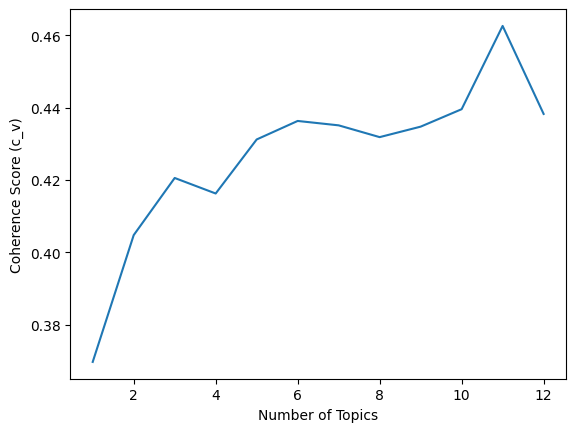

In [13]:
topic_range = range(1, 13)
coherence_scores = compute_coherence_values(topic_range)

for k, score in zip(topic_range, coherence_scores):
    print(f"Topics: {k}, Coherence: {score:.4f}")

plt.plot(topic_range, coherence_scores)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score (c_v)")
plt.show()